# Explore GDN Results

This notebook is for visual exploration of already-generated analysis outputs. Run `python scripts/run_analysis.py` first if you need to regenerate the exported tables and figures.

In [3]:
from pathlib import Path
import json
import sys

import pandas as pd
from IPython.display import Image, display

PROJECT_ROOT = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve()
SRC_DIR = PROJECT_ROOT
if str(SRC_DIR) not in sys.path:
    sys.path.insert(0, str(SRC_DIR))

from src.io import NETWORK_ORDER


## Discover exported outputs

This notebook inspects the committed `result_files/` artifacts for each network.

In [4]:
network_outputs = {}
for network_name in NETWORK_ORDER:
    results_dir = PROJECT_ROOT / network_name / 'result_files'
    network_outputs[network_name] = {
        'results_dir': results_dir,
        'has_outputs': results_dir.exists(),
        'files': sorted(path.name for path in results_dir.glob('*')) if results_dir.exists() else [],
    }

display(pd.DataFrame([
    {
        'network': network_name,
        'results_dir': str(info['results_dir']),
        'has_outputs': info['has_outputs'],
        'file_count': len(info['files']),
    }
    for network_name, info in network_outputs.items()
]))

,network,results_dir,has_outputs,file_count
0,T_Network,C:\Frank\Work\ICIMAF\GDN\T_Network\result_files,True,9
1,N_Network,C:\Frank\Work\ICIMAF\GDN\N_Network\result_files,True,9


## Graph-level summary

In [5]:
graph_summaries = []
for network_name, info in network_outputs.items():
    summary_path = info['results_dir'] / 'graph_metrics_summary.json'
    if not summary_path.exists():
        continue
    graph_summaries.append(json.loads(summary_path.read_text(encoding='utf-8')))

display(pd.DataFrame(graph_summaries))

,network,label,n_nodes,n_edges,n_samples,density,max_in_degree,mean_in_degree,max_out_degree,mean_out_degree,isolated_nodes,orphan_nodes,childless_nodes,maximum_diameter,mean_diameter,directed_reachable_diameter,directed_mean_reachable_distance,largest_wcc_size,largest_wcc_undirected_diameter,distance_method
0,T_Network,T,6138,110953,499,0.002945,239,18.076409,281,18.076409,129,1605,513,12,2.583464,12,2.583464,5989,9,scipy_shortest_path
1,N_Network,N,492,4822,52,0.019961,54,9.800813,163,9.800813,1,9,93,9,2.444751,9,2.444751,491,7,scipy_shortest_path


## Vertex metrics preview

In [6]:
for network_name, info in network_outputs.items():
    vertex_path = info['results_dir'] / 'vertex_metrics.csv'
    if not vertex_path.exists():
        continue
    print(network_name)
    display(pd.read_csv(vertex_path).head())

T_Network


,node_id,name,frequency,in_degree,out_degree
0,0,ENSG00000001036,0.166333,1,3
1,1,ENSG00000001497,0.146293,8,24
2,2,ENSG00000001629,0.116232,32,58
3,3,ENSG00000001631,0.158317,36,18
4,4,ENSG00000002330,0.150301,31,10


N_Network


,node_id,name,frequency,in_degree,out_degree
0,0,ENSG00000000005,0.846154,14,4
1,1,ENSG00000003137,0.923077,40,2
2,2,ENSG00000003147,0.884615,10,11
3,3,ENSG00000004799,0.903846,5,6
4,4,ENSG00000005189,0.865385,29,13


## Sample activation metrics preview

In [8]:
for network_name, info in network_outputs.items():
    sample_path = info['results_dir'] / 'sample_activation_metrics.csv'
    if not sample_path.exists():
        continue
    print(network_name)
    display(pd.read_csv(sample_path).head())

T_Network


,sample_index,spontaneous_active,total_active
0,0,647,1990
1,1,389,904
2,2,517,1446
3,3,161,269
4,4,307,885


N_Network


,sample_index,spontaneous_inactive,total_inactive
0,0,10,489
1,1,9,482
2,2,12,459
3,3,9,485
4,4,14,311


## Exported figures

T_Network


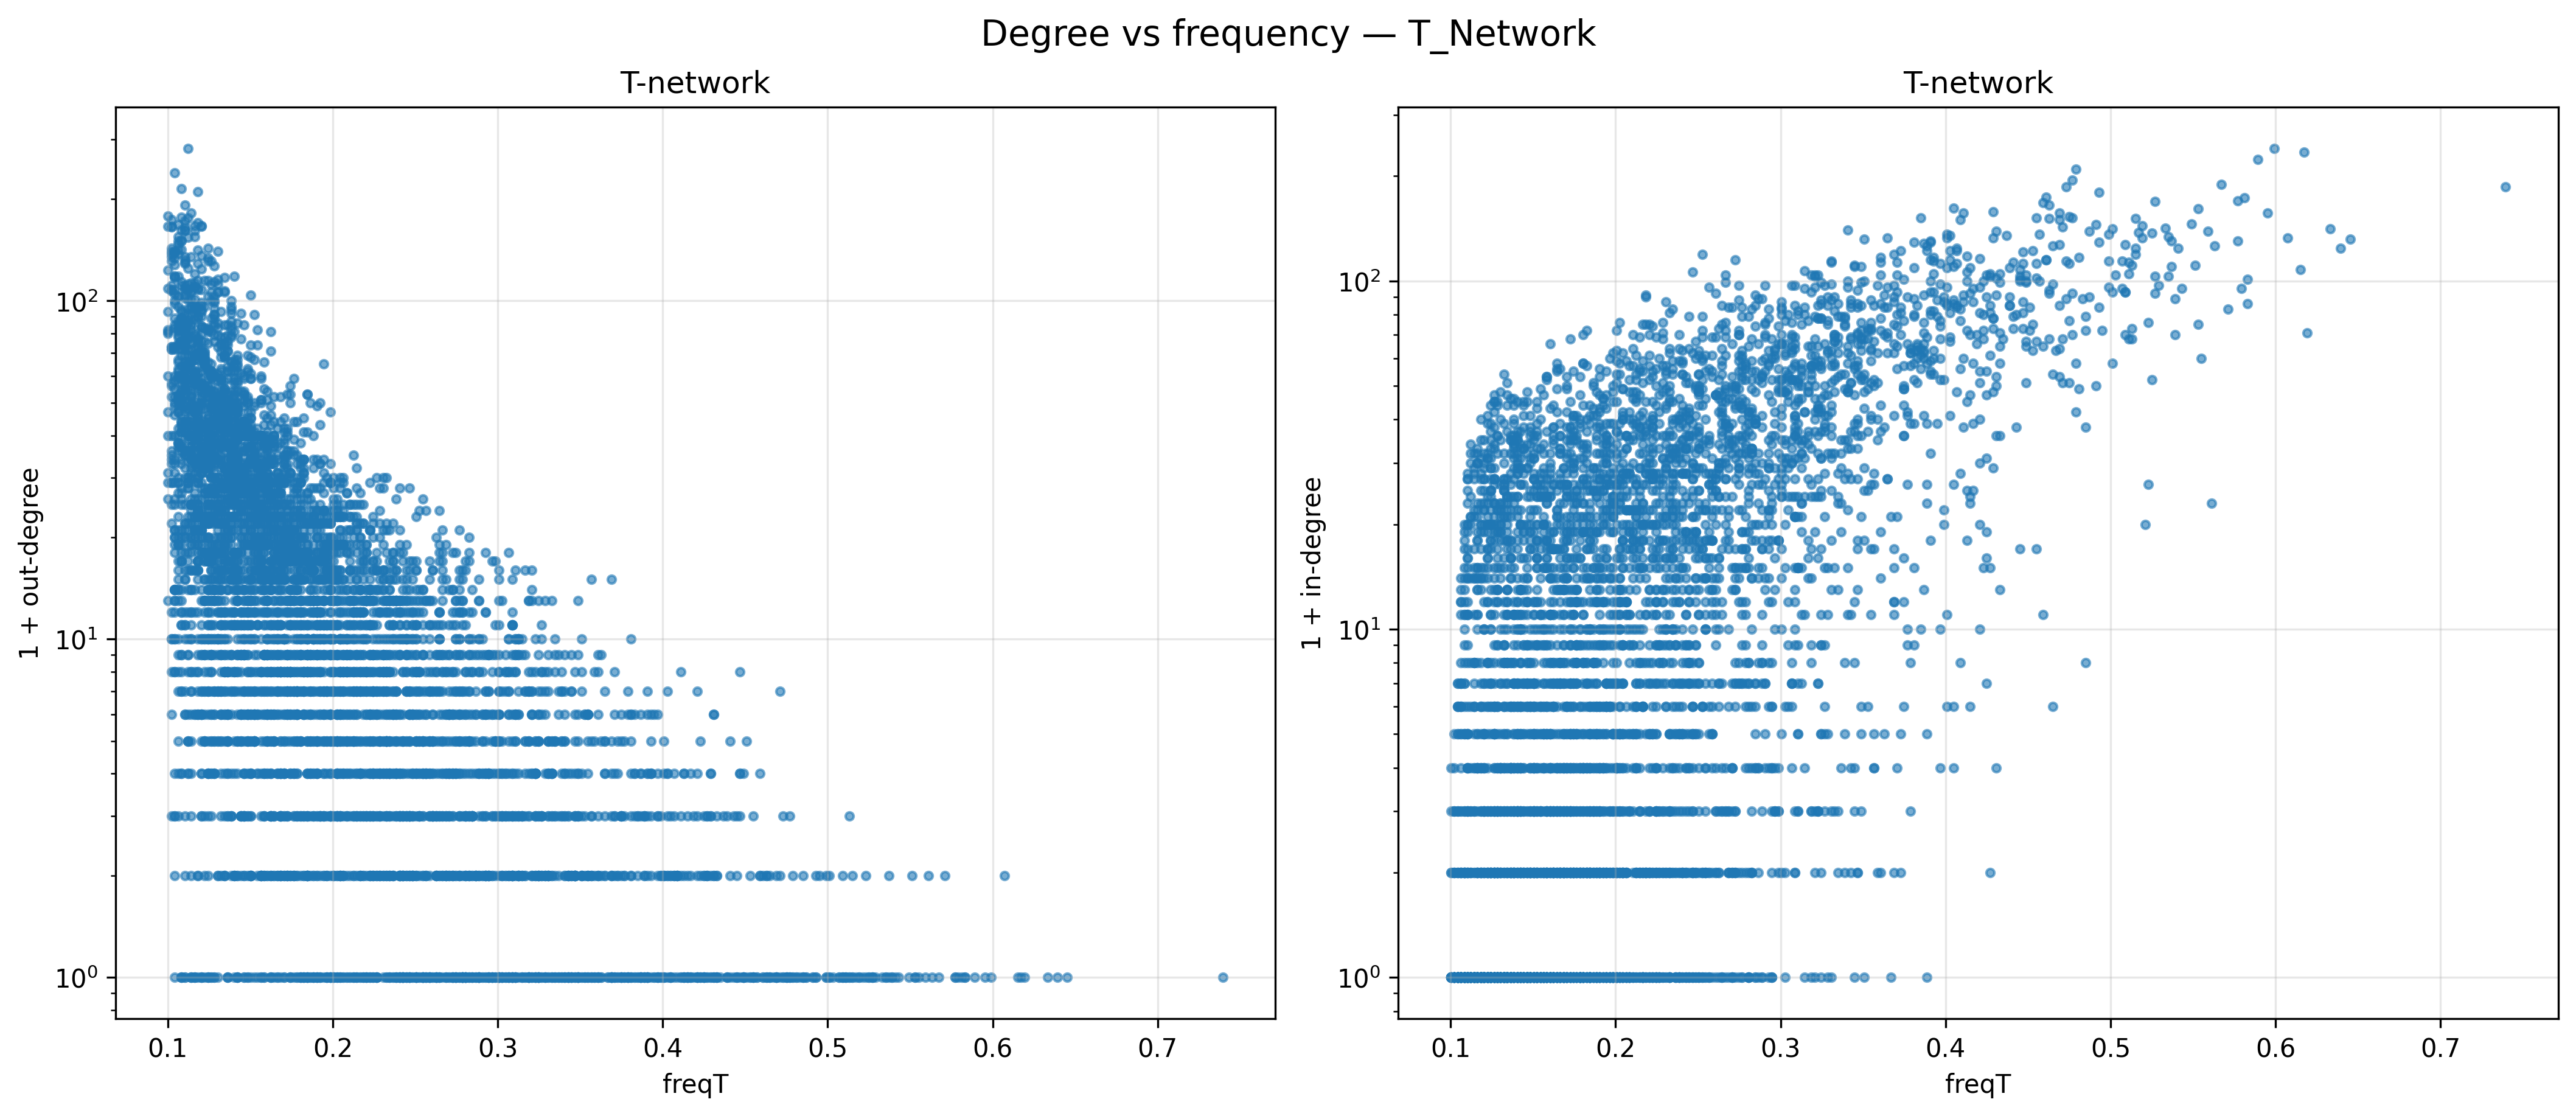

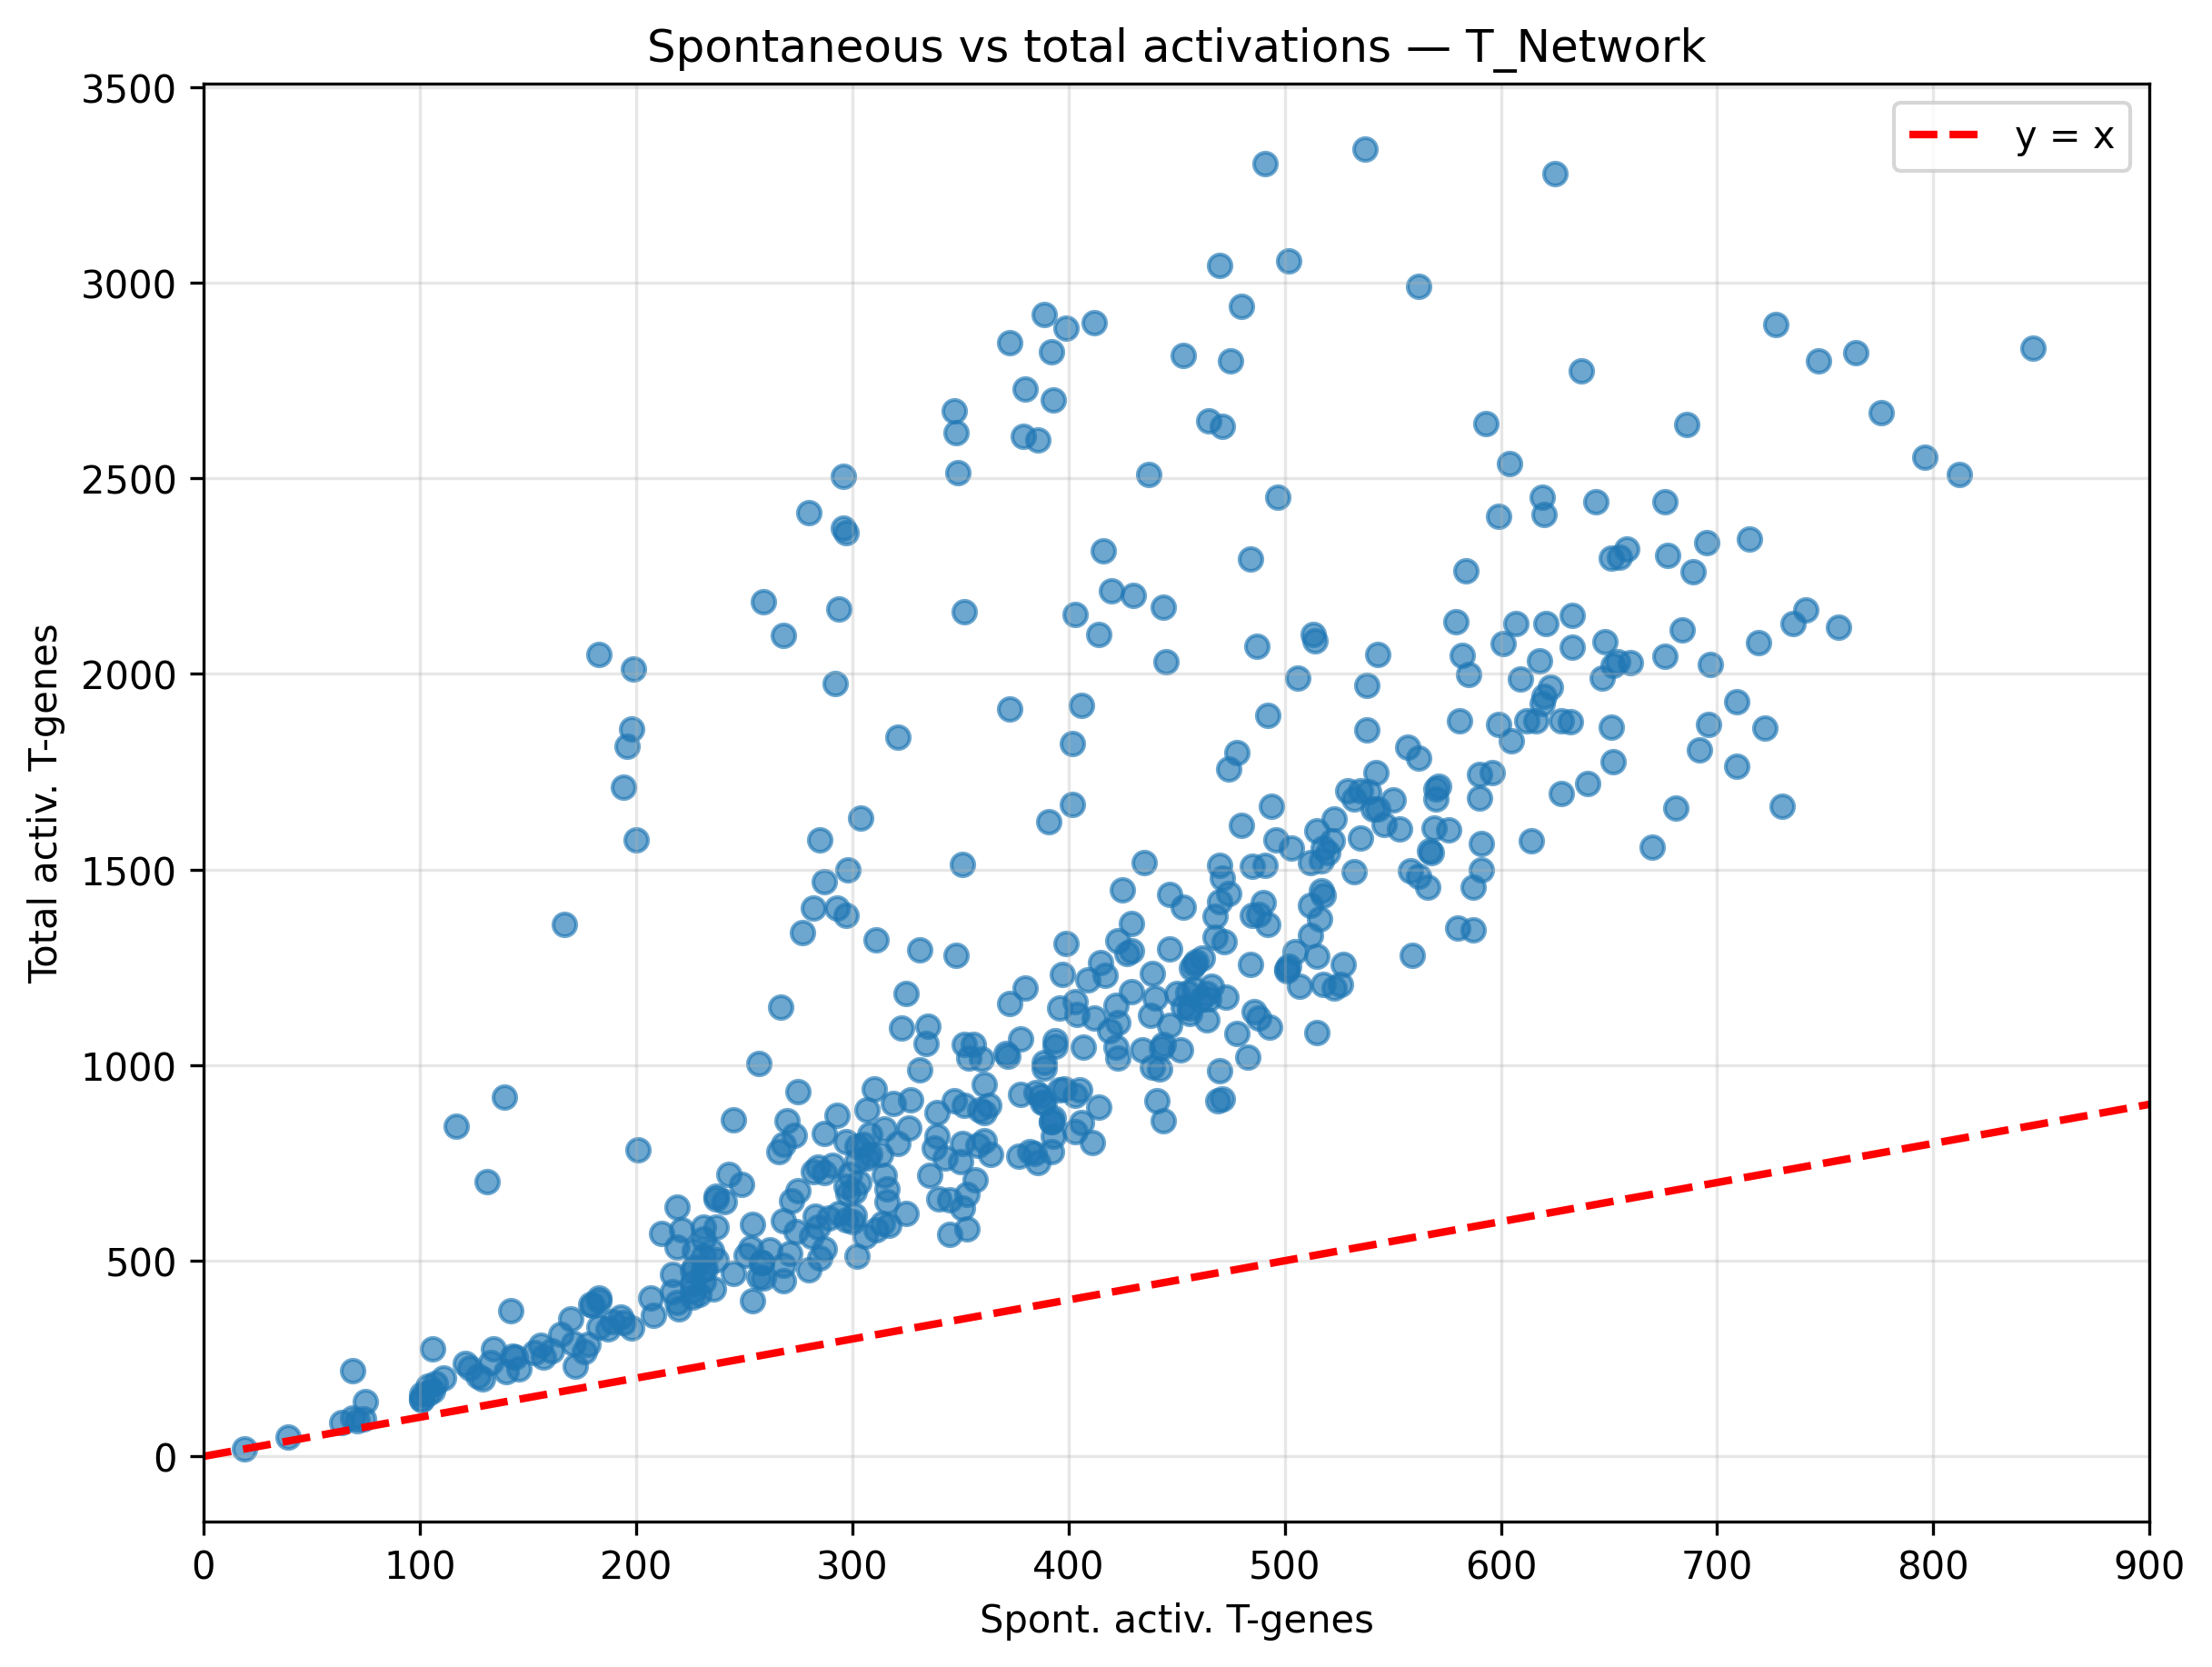

N_Network


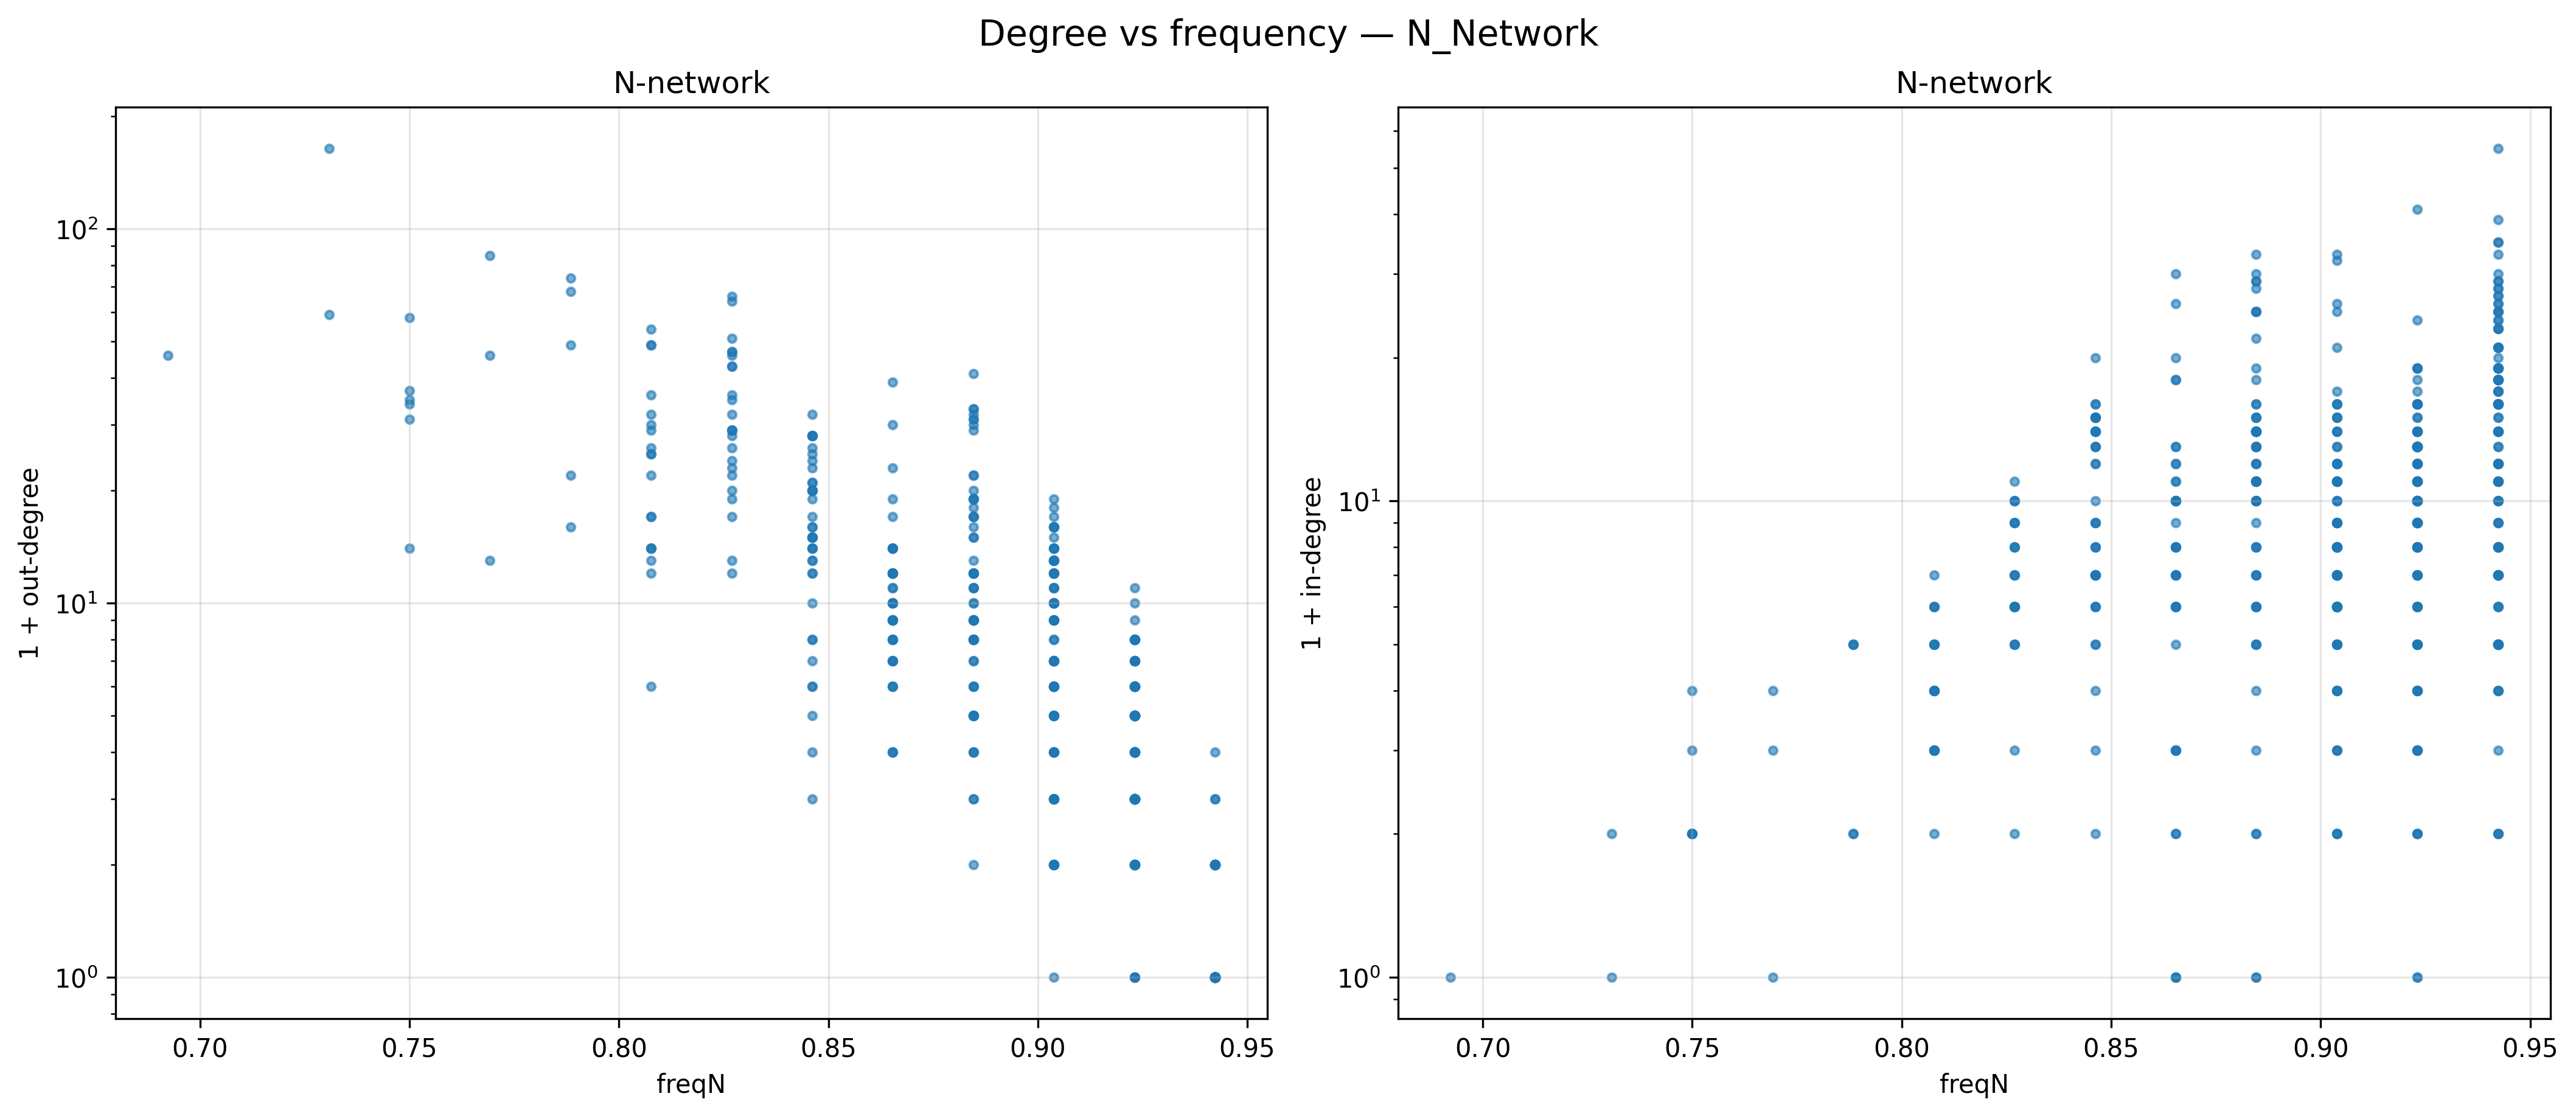

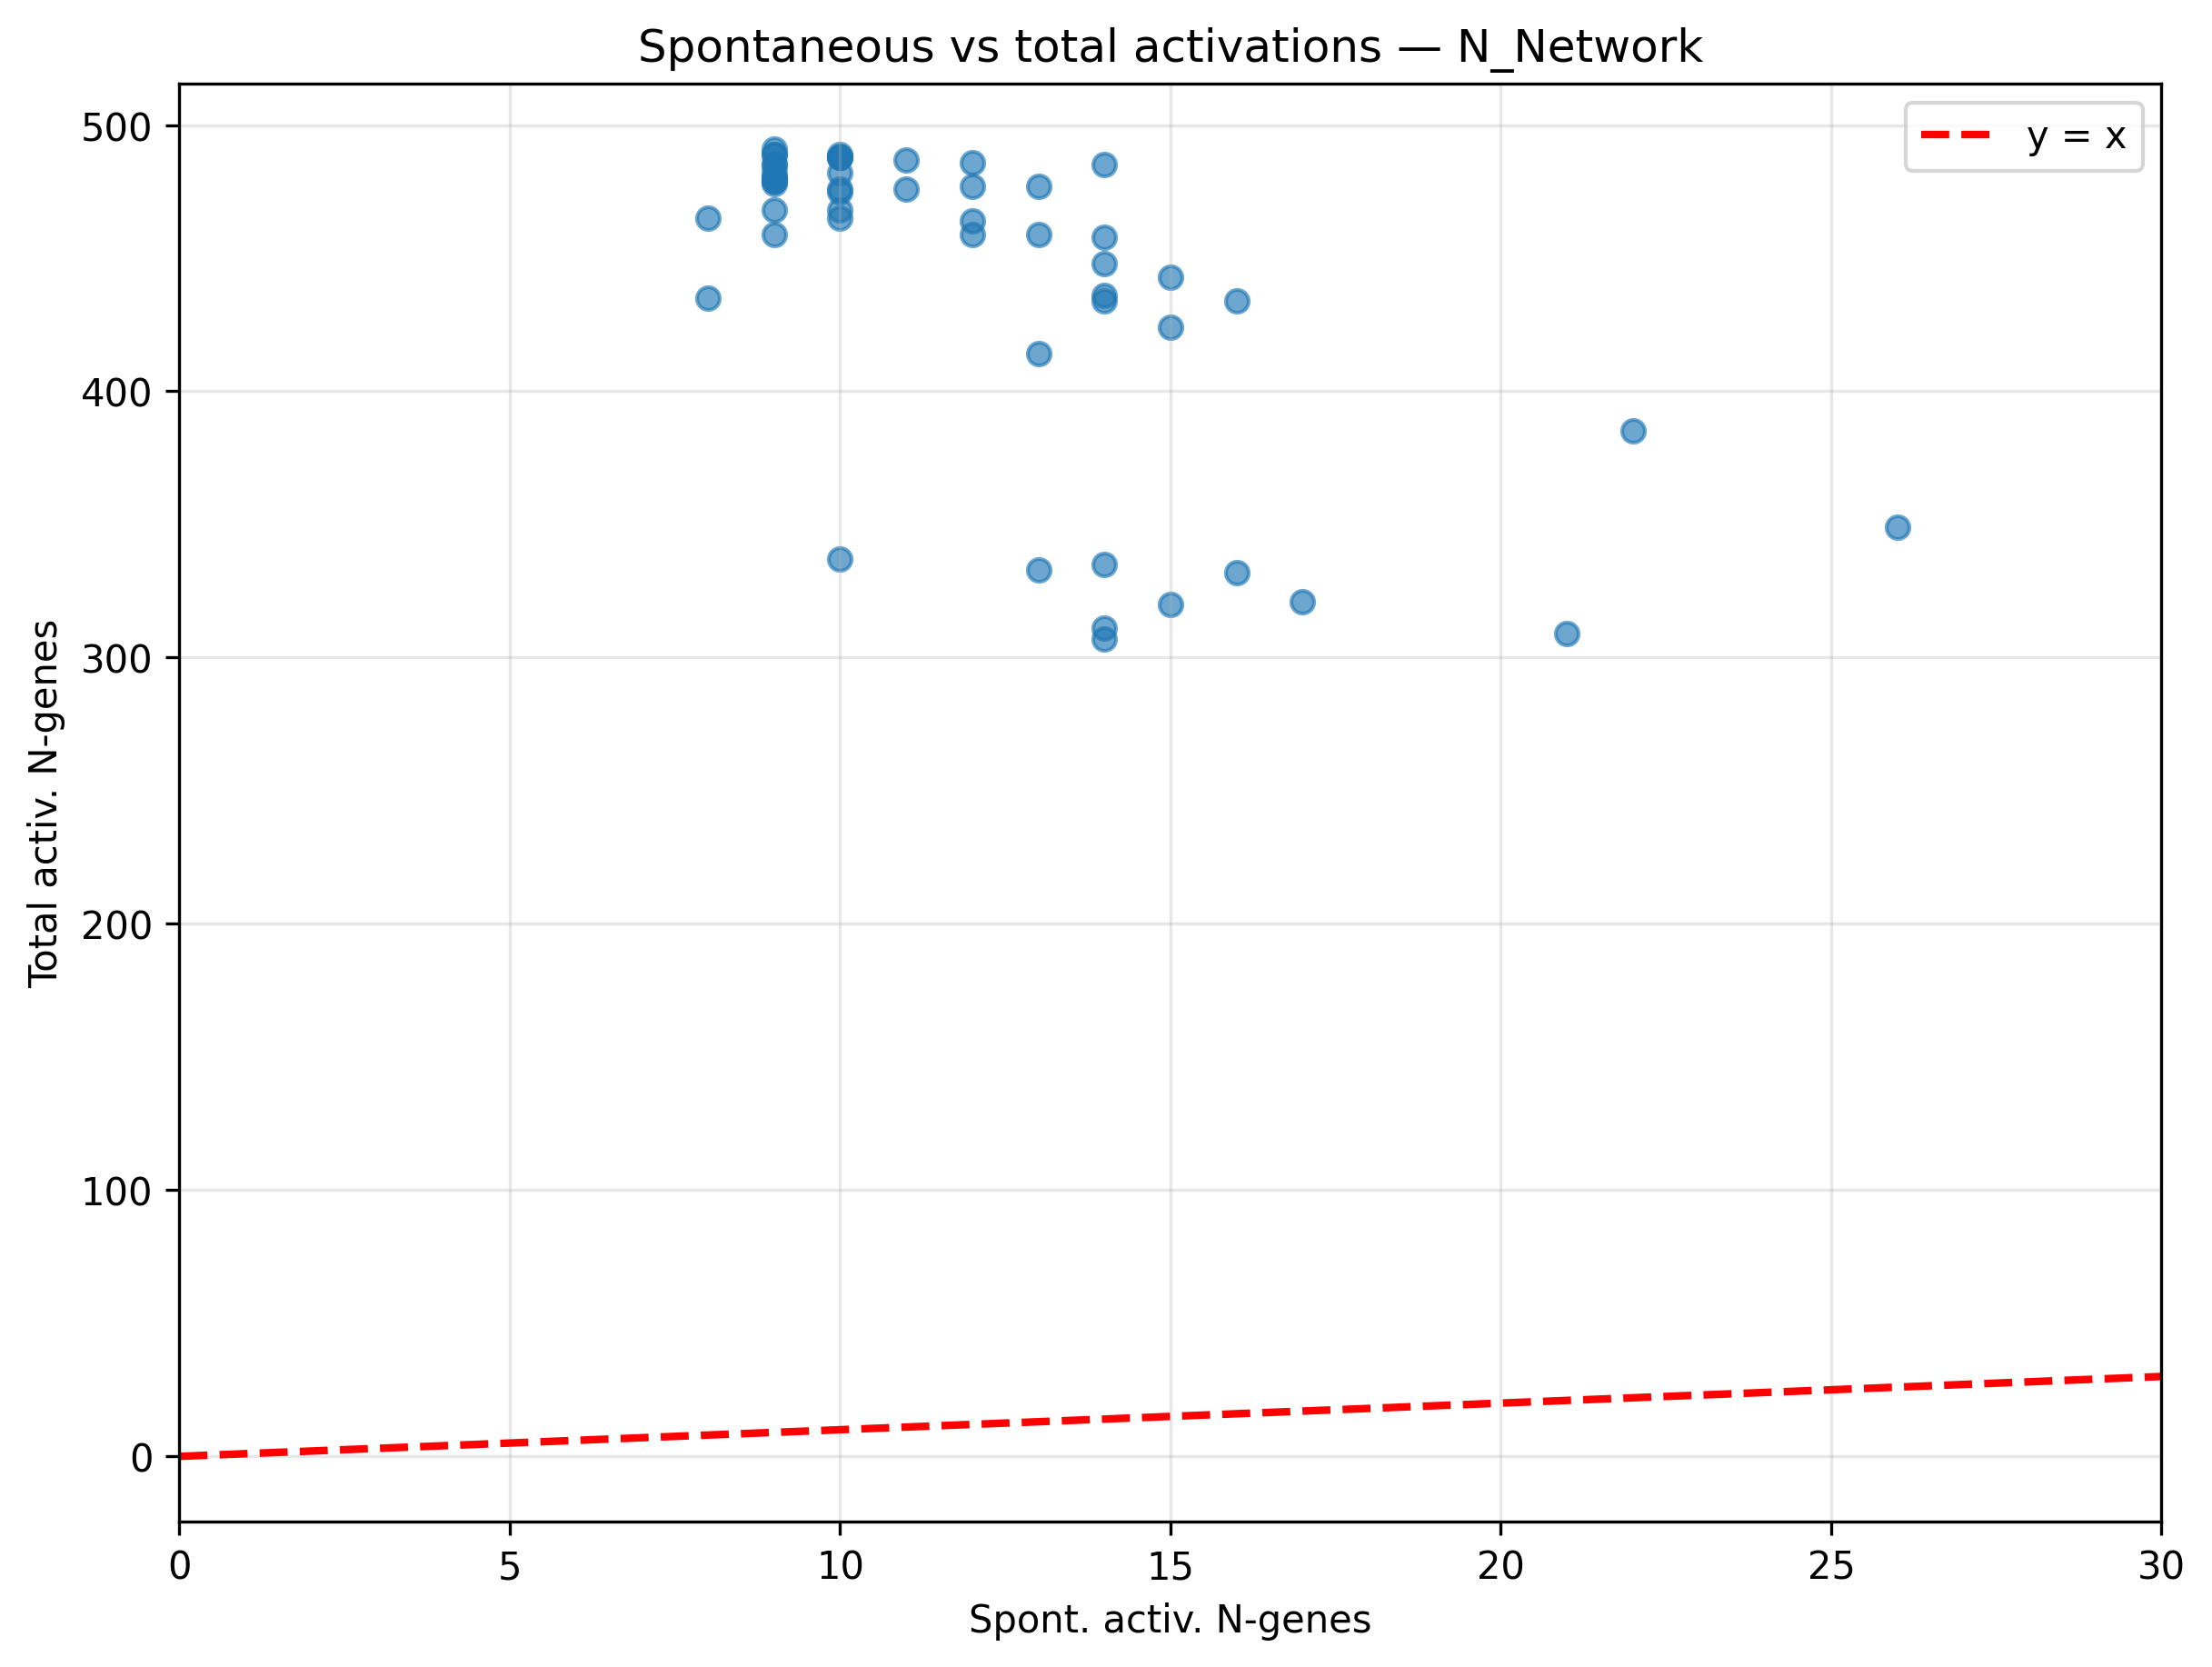

In [9]:
for network_name, info in network_outputs.items():
    print(network_name)
    for file_name in ['figure1_degree_vs_frequency.png', 'figure2_spontaneous_vs_total.png']:
        image_path = info['results_dir'] / file_name
        if image_path.exists():
            display(Image(filename=str(image_path)))